In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Look and Feel für die Plots definieren
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# 1. Daten laden und Timestamp direkt als Index setzen
df = pd.read_csv(
    "../data/external/aws_cpu_utilization.csv",
    parse_dates=["timestamp"],
    index_col="timestamp"
)

# 2. Datensatz-Eigenschaften prüfen
print("--- Datensatz Info ---")
print(df.info())
print("\n--- Fehlende Werte ---")
print(df.isna().sum())

# 3. Die ersten Zeilen anzeigen
df.head()

--- Datensatz Info ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4032 entries, 2014-04-10 00:02:00 to 2014-04-23 23:57:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   4032 non-null   float64
dtypes: float64(1)
memory usage: 63.0 KB
None

--- Fehlende Werte ---
value    0
dtype: int64


,value
timestamp,
2014-04-10 00:02:00,14.012
2014-04-10 00:07:00,13.334
2014-04-10 00:12:00,15.000
2014-04-10 00:17:00,13.998
2014-04-10 00:22:00,14.332


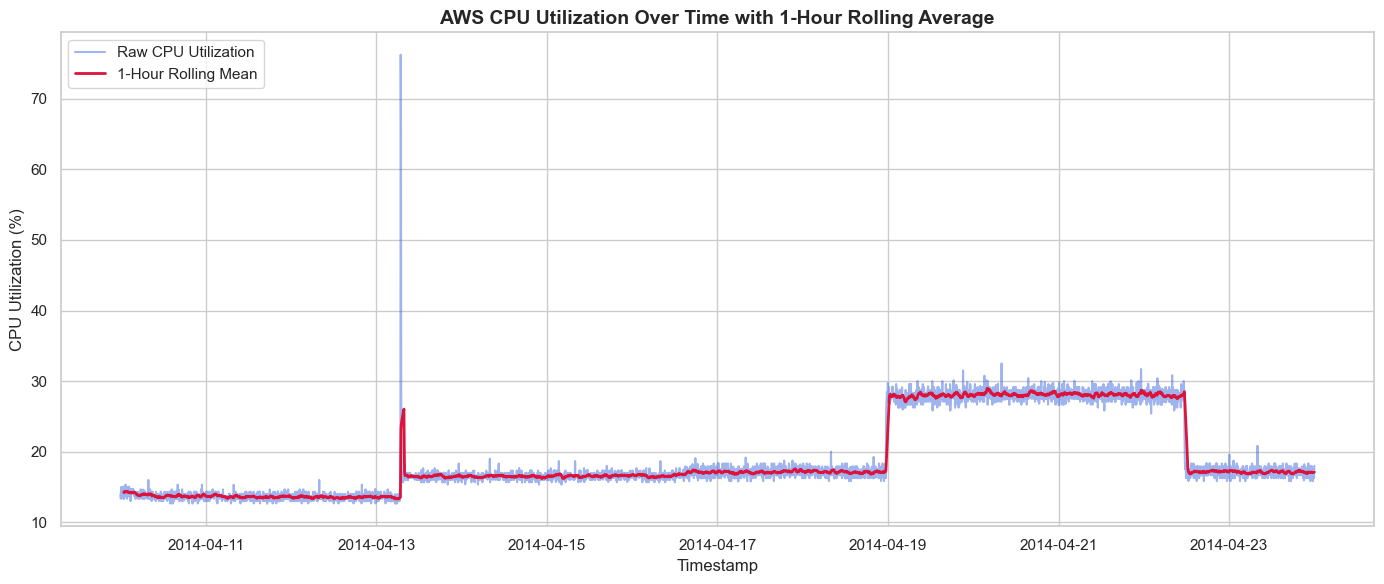

In [2]:
# Die rohen CPU-Werte plotten
plt.plot(df.index, df['value'], label='Raw CPU Utilization', alpha=0.5, color='royalblue')

# Einen gleitenden Mittelwert über 12 Schritte (12 * 5 Min = 1 Stunde) berechnen und plotten
df['rolling_mean_1h'] = df['value'].rolling(window=12).mean()
plt.plot(df.index, df['rolling_mean_1h'], label='1-Hour Rolling Mean', color='crimson', linewidth=2)

plt.title('AWS CPU Utilization Over Time with 1-Hour Rolling Average', fontsize=14, fontweight='bold')
plt.xlabel('Timestamp')
plt.ylabel('CPU Utilization (%)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

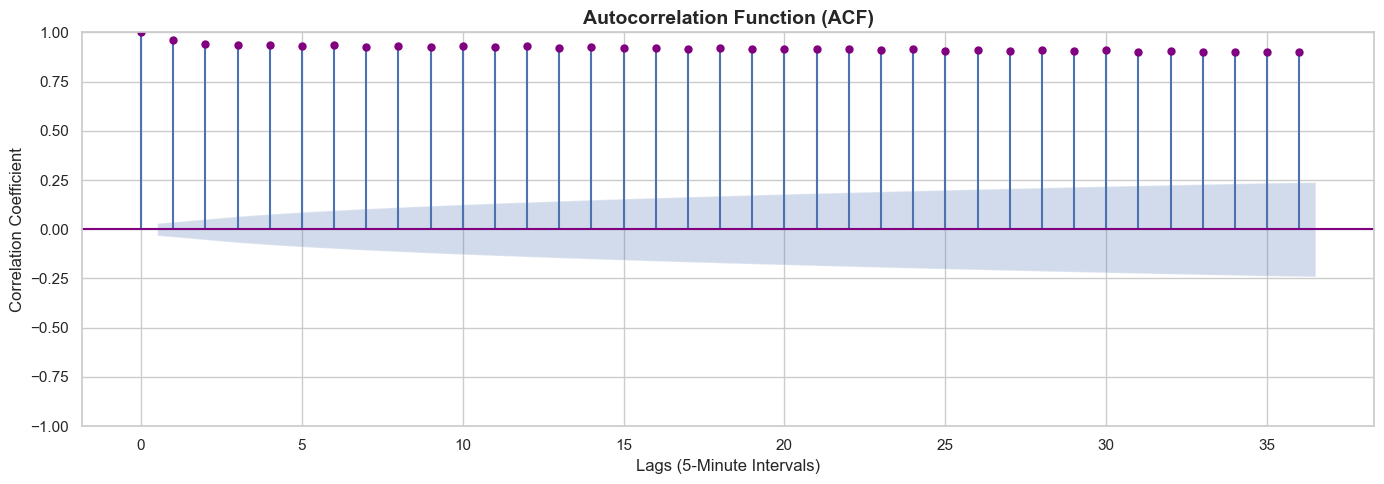

In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Wir plotten die Autokorrelation für die letzten 36 Schritte (36 * 5 Min = 3 Stunden)
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(df['value'], lags=36, ax=ax, color='purple')

plt.title('Autocorrelation Function (ACF)', fontsize=14, fontweight='bold')
plt.xlabel('Lags (5-Minute Intervals)')
plt.ylabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [4]:
# --- DATA QUALITY & QUICK CHECK ---

# 1. Shape und Datenpunkte
anzahl_zeilen, anzahl_spalten = df.shape
print(f"Das DataFrame hat {anzahl_zeilen} Datenpunkte (Zeilen) und {anzahl_spalten} Spalte(n).")

# Zeitliche Abdeckung und Frequenz berechnen
zeit_min = df.index.min()
zeit_max = df.index.max()
zeit_spanne = zeit_max - zeit_min
print(f"Zeitraum: Von {zeit_min} bis {zeit_max} (Spanne: {zeit_spanne.days} Tage)")

# 2. Datentypen prüfen
print("\n--- Datentypen der Spalten ---")
print(df.dtypes)

# 3. Fehlende Werte (Missing Values) prüfen
missing_values = df.isna().sum().sum()
print(f"\nFehlende Werte im gesamten Datensatz: {missing_values}")

# 4. Statistische Kurzübersicht
print("\n--- Statistische Kennzahlen ---")
df.describe()

Das DataFrame hat 4032 Datenpunkte (Zeilen) und 2 Spalte(n).
Zeitraum: Von 2014-04-10 00:02:00 bis 2014-04-23 23:57:00 (Spanne: 13 Tage)

--- Datentypen der Spalten ---
value              float64
rolling_mean_1h    float64
dtype: object

Fehlende Werte im gesamten Datensatz: 11

--- Statistische Kennzahlen ---


,value,rolling_mean_1h
count,4032.000000,4021.000000
mean,18.934868,18.943887
std,5.605191,5.447327
min,12.628000,13.305000
25%,15.835000,16.361833
50%,16.677500,16.960208
75%,25.521250,25.401083
max,76.230000,28.997500


In [5]:
import numpy as np

# Wir arbeiten auf einer Kopie, um das originale df sauber zu halten
features_df = df[['value']].copy()

# 1. Lag Features erstellen (die letzten 3 Zeitschritte)
for lag in range(1, 4):
    features_df[f'lag_{lag}'] = features_df['value'].shift(lag)

# 2. Rolling Statistics (Volatilität und Niveau der letzten 1 & 6 Stunden)
features_df['rolling_mean_1h'] = features_df['value'].rolling(window=12).mean()
features_df['rolling_std_1h'] = features_df['value'].rolling(window=12).std()

features_df['rolling_mean_6h'] = features_df['value'].rolling(window=72).mean()
features_df['rolling_std_6h'] = features_df['value'].rolling(window=72).std()

# 3. Zeitkomponenten extrahieren (als numerische Werte)
features_df['hour'] = features_df.index.hour
features_df['day_of_week'] = features_df.index.dayofweek

# Durch das Rolling Window entstehen am Anfang NaN-Werte -> sauber droppen
features_df.dropna(inplace=True)

print(f"Form des Feature-Datensatzes: {features_df.shape}")
features_df.head()

Form des Feature-Datensatzes: (3961, 10)


,value,lag_1,lag_2,lag_3,rolling_mean_1h,rolling_std_1h,rolling_mean_6h,rolling_std_6h,hour,day_of_week
timestamp,,,,,,,,,,
2014-04-10 05:57:00,14.332,13.668,13.666,14.668,13.856833,0.390749,14.121222,0.515774,5,3
2014-04-10 06:02:00,14.334,14.332,13.668,13.666,13.940333,0.375149,14.125694,0.516209,6,3
2014-04-10 06:07:00,13.336,14.334,14.332,13.668,13.916833,0.404834,14.125722,0.516166,6,3
2014-04-10 06:12:00,13.666,13.336,14.334,14.332,13.916833,0.404834,14.107194,0.508223,6,3
2014-04-10 06:17:00,13.994,13.666,13.336,14.334,13.916333,0.404726,14.107139,0.508235,6,3


In [6]:
# --- FEATURE EXPANSION ---
df_enriched = df[['value']].copy()

# 1. Lokale Zeitkomponenten extrahieren
df_enriched['hour'] = df_enriched.index.hour
df_enriched['day_of_week'] = df_enriched.index.dayofweek
df_enriched['is_weekend'] = df_enriched['day_of_week'].isin([5, 6]).astype(int)

# 2. Zyklische Transformation der Uhrzeit (Sinus/Cosinus)
df_enriched['hour_sin'] = np.sin(2 * np.pi * df_enriched['hour'] / 24.0)
df_enriched['hour_cos'] = np.cos(2 * np.pi * df_enriched['hour'] / 24.0)

# 3. Erweiterte Rolling-Features (1 Stunde & 6 Stunden)
df_enriched['rolling_mean_1h'] = df_enriched['value'].rolling(window=12).mean()
df_enriched['rolling_std_1h'] = df_enriched['value'].rolling(window=12).std()

df_enriched['rolling_mean_6h'] = df_enriched['value'].rolling(window=72).mean()
df_enriched['rolling_std_6h'] = df_enriched['value'].rolling(window=72).std()

# 4. NaNs eliminieren (die durch das 6h-Fenster entstehenden ersten 71 Zeilen)
df_enriched.dropna(inplace=True)

print(f"Neue Form des erweiterten Datensatzes: {df_enriched.shape}")
print(f"Verfügbare Features für PyTorch: {list(df_enriched.columns)}")

Neue Form des erweiterten Datensatzes: (3961, 10)
Verfügbare Features für PyTorch: ['value', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'rolling_mean_1h', 'rolling_std_1h', 'rolling_mean_6h', 'rolling_std_6h']


### 📝 Erkenntnisse aus der Explorativen Datenanalyse (EDA) & Data Quality

* **Datenqualität & Datenpunkte:** Der Rohdatensatz umfasst 4.032 Datenpunkte über eine Spanne von knapp 14 Tagen. Es gibt keine nativen Lücken in den Rohdaten.
* **Erklärung der Missing Values:** Der Quick-Check zeigte temporär 11 fehlende Werte bei `rolling_mean_1h`. Dies ist mathematisch bedingt (Edge-Effekt des gleitenden Durchschnitts), da für das 1-Stunden-Fenster (12 Schritte) die ersten 11 Einträge keine ausreichende Historie besitzen. Diese wurden im Zuge des Feature Engineerings zusammen mit den 6-Stunden-Edge-Effekten (71 Zeilen) konsistent via `.dropna()` entfernt.
* **Anomalie-Identifikation:** Die statistischen Kennzahlen zeigen ein Maximum von 76,23% CPU-Last, während das 75%-Quantil bei nur 25,52% liegt. Dies untermauert die visuelle Beobachtung des extremen, singulären Peaks am 13. April (potenzielle Anomalie).
* **Feature-Erweiterung:** Um der geringen Dimensionalität der Rohdaten entgegenzuwirken, wurde der Datensatz von 1 auf 10 Features erweitert. Die zeitliche Dynamik wird nun durch zyklisch kodierte Stunden-Vektoren (`hour_sin`, `hour_cos`), Wochenend-Indikatoren sowie Volatilitätsmetriken (`rolling_std`) abgebildet, was dem PyTorch-Modell tiefen Kontext liefert.